In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler


In [ ]:
df = pd.read_csv('income.csv')
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


Text(0, 0.5, 'Income')

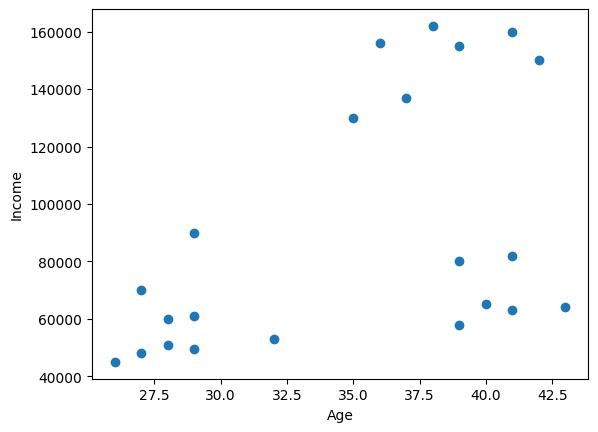

In [ ]:
plt.scatter(df['Age'],df['Income($)'])

plt.xlabel("Age")
plt.ylabel("Income")

In [ ]:
km = KMeans(n_clusters = 3)

In [ ]:
y_pred = km.fit_predict(df[["Age","Income($)"]])

In [ ]:
y_pred

array([0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2],
      dtype=int32)

In [ ]:
df['cluster'] = y_pred

In [ ]:
df

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


In [ ]:
km.cluster_centers_

array([[3.40000000e+01, 8.05000000e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.29090909e+01, 5.61363636e+04]])

In [ ]:
df1 =  df[df['cluster'] == 0]
df2 =  df[df['cluster'] == 1]
df3 =  df[df['cluster'] == 2]

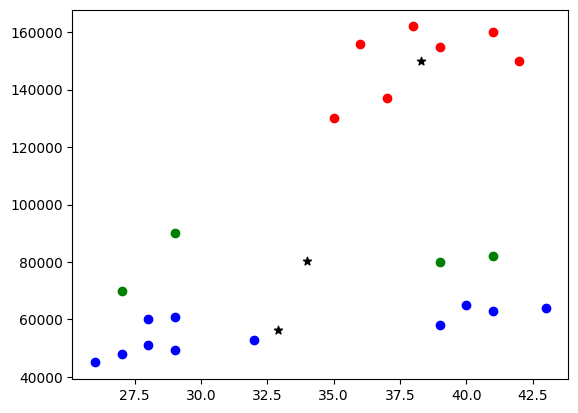

In [ ]:
plt.scatter(df1['Age'],df1['Income($)'],color = 'green')
plt.scatter(df2['Age'],df2['Income($)'],color = 'red')
plt.scatter(df3['Age'],df3['Income($)'],color = 'blue')

a = km.cluster_centers_

plt.scatter(a[:,0],a[:,1],color = 'black',marker = "*", label = "Centroid")

In [ ]:
#Preprocessing #feature scalling
scaler = MinMaxScaler()

#first i Fit the income
scaler.fit(df[['Income($)']])

#then I tranform the income and update the originAL DF
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [ ]:
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


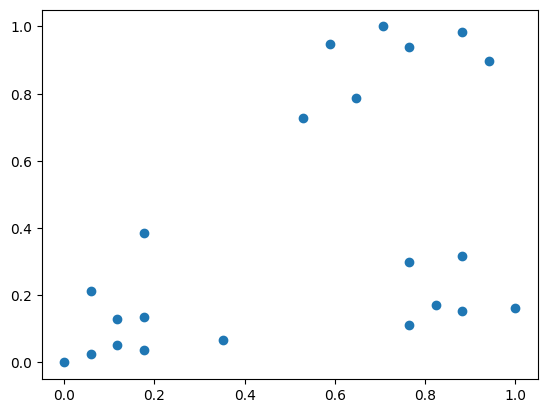

In [ ]:
plt.scatter(df.Age,df['Income($)'])

In [ ]:
km1 = KMeans(n_clusters = 3)
y_pred = km1.fit_predict(df[['Age','Income($)']])
y_pred

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [ ]:
df['cluster'] = y_pred

In [ ]:
km1.cluster_centers_

array([[0.85294118, 0.2022792 ],
       [0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ]])

In [ ]:
df1 = df[df['cluster']==0]
df2 = df[df['cluster']==1]
df3 = df[df['cluster']==2]

Text(0, 0.5, 'Income')

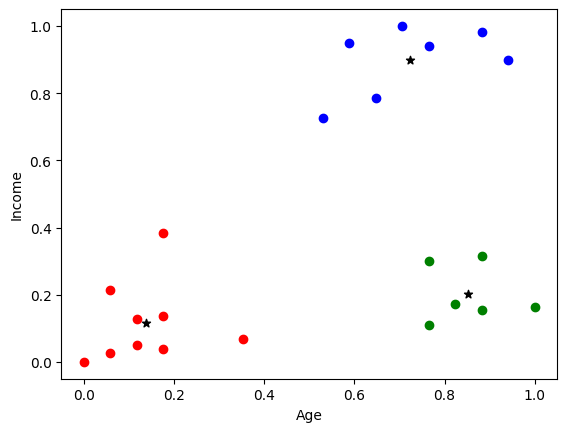

In [ ]:
plt.scatter(df1['Age'],df1['Income($)'],color = "green")
plt.scatter(df2['Age'],df2['Income($)'],color = "red")
plt.scatter(df3['Age'],df3['Income($)'],color = "Blue")
plt.scatter(km1.cluster_centers_[:,0],km1.cluster_centers_[:,1],color = "black",marker = "*",label = "Centroid")

plt.xlabel("Age")
plt.ylabel('Income')

In [ ]:
#Elbow method

sse = []
k_rng = range(1,10)

for k in k_rng:
  km = KMeans(n_clusters = k)
  km.fit(df[['Age','Income($)']])
  sse.append(km.inertia_)


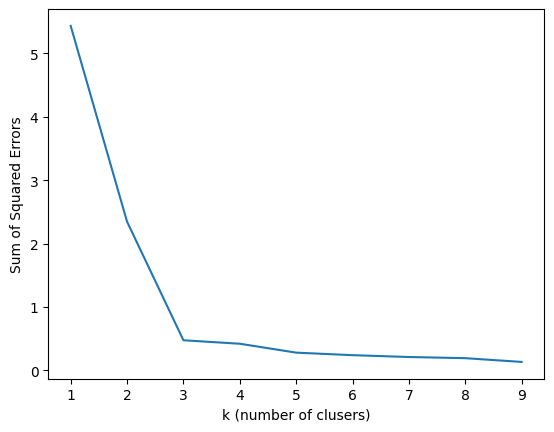

In [ ]:
plt.xlabel("k (number of clusers)")
plt.ylabel("Sum of Squared Errors")
plt.plot(k_rng,sse)

